# COVID-19 India Analysis (2020–2021)

## Exploratory Data Analysis using Python, Pandas, Matplotlib & Seaborn

### Project Objectives
- Analyze COVID-19 trends across India from January 2020 to October 2021.
- Explore daily and monthly confirmed, recovered, and deceased cases.
- Perform state-wise COVID-19 analysis.
- Calculate recovery and fatality rates using feature engineering.
- Visualize pandemic trends through 18 analytical charts.
- Identify the first and second COVID-19 waves in India.
- Study relationships between different COVID-19 metrics using correlation analysis.
- Build a portfolio-quality data analysis project suitable for GitHub and interviews.

---

**Tools Used:** Python • Pandas • NumPy • Matplotlib • Seaborn

**Dataset:** COVID-19 India Dataset (2020–2021)

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
states = pd.read_csv("data/raw_data_Indian_states.csv")
cases = pd.read_csv("data/case_time_series.csv")

In [98]:
print(states.head())
print(cases.head())

         Date   State  Confirmed  Recovered  Deceased  Other  Tested
0  2020-01-30  Kerala          1          0         0      0     NaN
1  2020-01-30   India          1          0         0      0     NaN
2  2020-02-02  Kerala          2          0         0      0     NaN
3  2020-02-02   India          2          0         0      0     NaN
4  2020-02-03  Kerala          3          0         0      0     NaN
              Date    Date_YMD  Daily Confirmed  Total Confirmed  \
0  30 January 2020  2020-01-30                1                1   
1  31 January 2020  2020-01-31                0                1   
2  1 February 2020  2020-02-01                0                1   
3  2 February 2020  2020-02-02                1                2   
4  3 February 2020  2020-02-03                1                3   

   Daily Recovered  Total Recovered  Daily Deceased  Total Deceased  
0                0                0               0               0  
1                0                0  

In [99]:
print(states.shape)
print(cases.shape)

(21675, 7)
(641, 8)


In [100]:
states.info()
cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 21675 entries, 0 to 21674
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       21675 non-null  str    
 1   State      21675 non-null  str    
 2   Confirmed  21675 non-null  int64  
 3   Recovered  21675 non-null  int64  
 4   Deceased   21675 non-null  int64  
 5   Other      21675 non-null  int64  
 6   Tested     20912 non-null  float64
dtypes: float64(1), int64(4), str(2)
memory usage: 1.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Date             641 non-null    str  
 1   Date_YMD         641 non-null    str  
 2   Daily Confirmed  641 non-null    int64
 3   Total Confirmed  641 non-null    int64
 4   Daily Recovered  641 non-null    int64
 5   Total Recovered  641 non-null    int64
 6   Daily Deceased   641 non-null    in

In [101]:
states.describe()

,Confirmed,Recovered,Deceased,Other,Tested
count,2.167500e+04,2.167500e+04,21675.000000,21675.000000,2.091200e+04
mean,7.555970e+05,7.124357e+05,10139.065836,281.688028,1.260827e+07
std,3.094074e+06,2.962147e+06,41461.658802,1338.299441,4.843699e+07
min,0.000000e+00,0.000000e+00,0.000000,-1.000000,5.800000e+01
25%,6.745500e+03,4.966500e+03,56.000000,0.000000,1.861295e+05
50%,6.701600e+04,5.882300e+04,850.000000,0.000000,1.184390e+06
75%,4.799305e+05,4.012895e+05,5358.000000,4.000000,9.974060e+06
max,3.428561e+07,3.366134e+07,458470.000000,13197.000000,6.092013e+08


In [102]:
cases.describe()

,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
count,641.000000,6.410000e+02,641.000000,6.410000e+02,641.000000,641.000000
mean,53487.361934,1.277492e+07,52513.544462,1.204517e+07,714.321373,171033.617785
std,78433.040215,1.236749e+07,76459.271069,1.201607e+07,979.005773,158531.839437
min,0.000000,1.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,12401.000000,7.690570e+05,11836.000000,4.765540e+05,142.000000,21147.000000
50%,30820.000000,9.932832e+06,32514.000000,9.455626e+06,414.000000,143540.000000
75%,55117.000000,2.694744e+07,57866.000000,2.404760e+07,835.000000,306671.000000
max,414280.000000,3.428540e+07,422391.000000,3.366118e+07,6139.000000,457880.000000


In [103]:
print(states.isna().sum())
print(cases.isna().sum())

Date           0
State          0
Confirmed      0
Recovered      0
Deceased       0
Other          0
Tested       763
dtype: int64
Date               0
Date_YMD           0
Daily Confirmed    0
Total Confirmed    0
Daily Recovered    0
Total Recovered    0
Daily Deceased     0
Total Deceased     0
dtype: int64


In [104]:
print(states.duplicated().sum())
print(cases.duplicated().sum())

0
0


In [105]:
states['Date'] = pd.to_datetime(states['Date'])
cases['Date'] = pd.to_datetime(cases['Date'])
cases['Date_YMD'] = pd.to_datetime(cases['Date_YMD'])

In [106]:
states.info()
cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 21675 entries, 0 to 21674
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       21675 non-null  datetime64[us]
 1   State      21675 non-null  str           
 2   Confirmed  21675 non-null  int64         
 3   Recovered  21675 non-null  int64         
 4   Deceased   21675 non-null  int64         
 5   Other      21675 non-null  int64         
 6   Tested     20912 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 1.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             641 non-null    datetime64[us]
 1   Date_YMD         641 non-null    datetime64[us]
 2   Daily Confirmed  641 non-null    int64         
 3   Total Confirmed  641 non-null    int64  

In [107]:
states['Year'] = states['Date'].dt.year
states['Month'] = states['Date'].dt.month
states['Month_Name'] = states['Date'].dt.month_name()

cases['Year'] = cases['Date_YMD'].dt.year
cases['Month'] = cases['Date_YMD'].dt.month
cases['Month_Name'] = cases['Date_YMD'].dt.month_name()

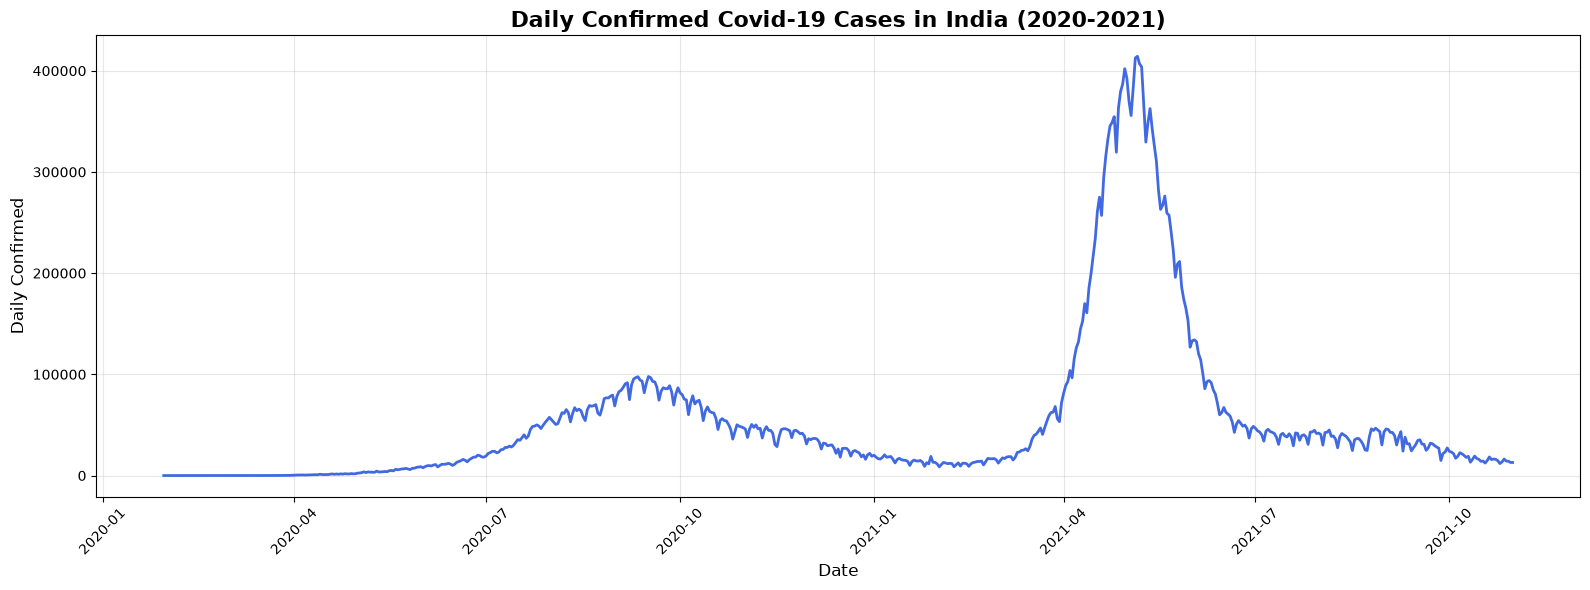

In [108]:
plt.figure(figsize = (16,6))
plt.plot(cases['Date_YMD'] , cases['Daily Confirmed'] , color = 'royalblue' , linewidth = 2)
plt.title("Daily Confirmed Covid-19 Cases in India (2020-2021)" , fontsize = 16 , fontweight = "bold")
plt.xlabel("Date" , fontsize = 12)
plt.ylabel("Daily Confirmed" , fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(alpha = 0.3)
plt.savefig("images/daily_confirmed_cases.png", dpi=300, bbox_inches="tight")
plt.show()

## 📊 Chart 1: Daily Confirmed COVID-19 Cases in India (2020–2021)

### 📌 Objective

Visualize the trend of daily confirmed COVID-19 cases in India over time to identify major waves and periods of rapid transmission.

### 📈 Why a Line Chart?

A line chart is ideal for showing changes over time. Since the data consists of daily confirmed cases across multiple dates, it clearly highlights trends, peaks, and declines.

### 🔍 Key Insights

- Daily confirmed cases remained low during the initial months of 2020.
- The first wave peaked around September 2020.
- A much larger second wave occurred during April–May 2021.
- The second wave recorded significantly higher daily cases than the first wave.
- After May 2021, daily confirmed cases gradually declined.

### 💼 Business / Public Health Insight

Monitoring daily confirmed cases helps governments and healthcare organizations predict outbreaks, allocate hospital resources, increase testing capacity, and implement timely public health interventions.

### 📚 Conclusion

The visualization clearly highlights India's two major COVID-19 waves, with the second wave being considerably more severe than the first.

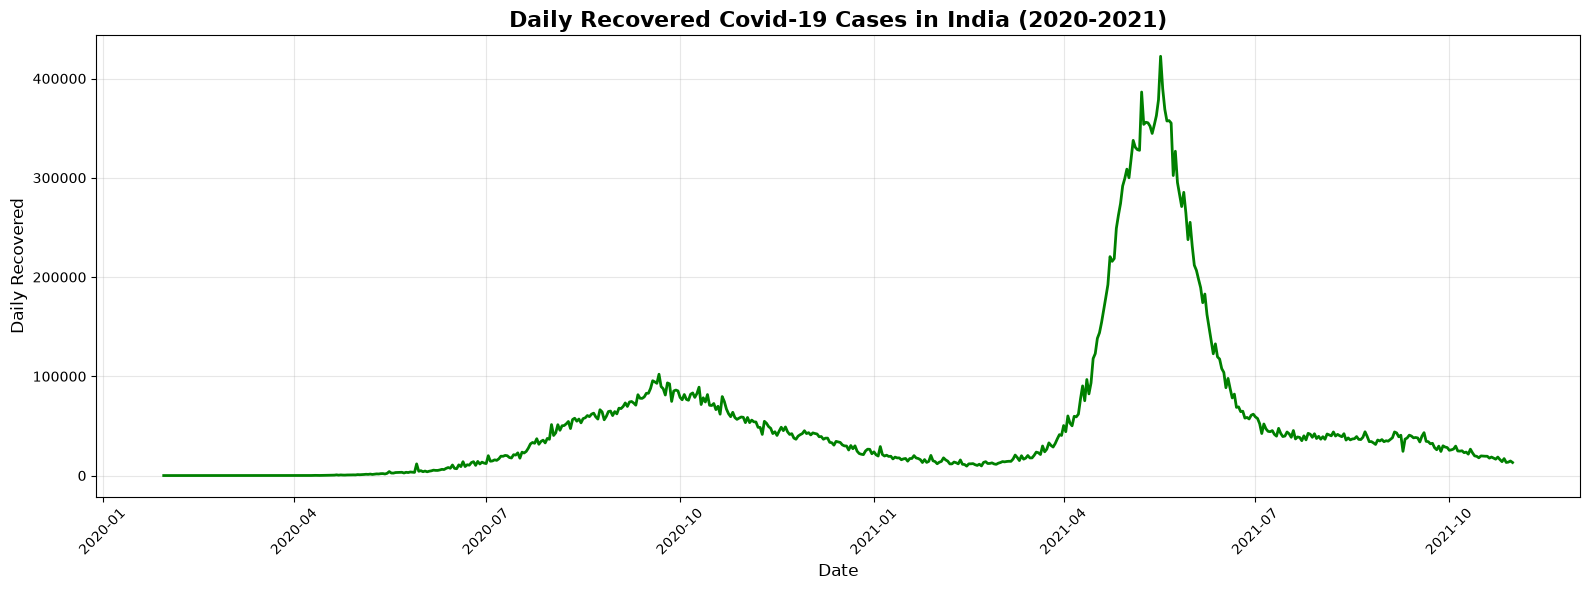

In [109]:
plt.figure(figsize = (16,6))
plt.plot(cases['Date_YMD'] , cases['Daily Recovered'] , color = 'green' , linewidth = 2)
plt.title("Daily Recovered Covid-19 Cases in India (2020-2021)" , fontsize = 16 , fontweight = "bold")
plt.xlabel("Date" , fontsize = 12)
plt.ylabel("Daily Recovered" , fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(alpha = 0.3)
plt.savefig("images/daily_recovered_cases.png", dpi=300, bbox_inches="tight")
plt.show()

## 📊 Chart 2: Daily Recovered COVID-19 Cases in India (2020–2021)

### 📌 Objective

Analyze how daily recoveries changed throughout the pandemic and compare recovery trends with infection waves.

### 📈 Why a Line Chart?

A line chart effectively represents daily recovery trends over time and helps identify periods when recoveries increased or decreased.

### 🔍 Key Insights

- Recoveries were initially very low during the early stages of the pandemic.
- Recovery numbers increased after each surge in confirmed cases.
- The highest number of daily recoveries occurred during the second wave in 2021.
- Recovery trends closely followed confirmed case trends, indicating successful patient recoveries after infection peaks.
- Recoveries gradually decreased as new infections declined.

### 💼 Business / Public Health Insight

Recovery trends help evaluate healthcare system performance and estimate hospital discharge rates, resource utilization, and pandemic recovery progress.

### 📚 Conclusion

The chart demonstrates that recovery rates improved significantly during both COVID-19 waves, reflecting the healthcare system's response over time.

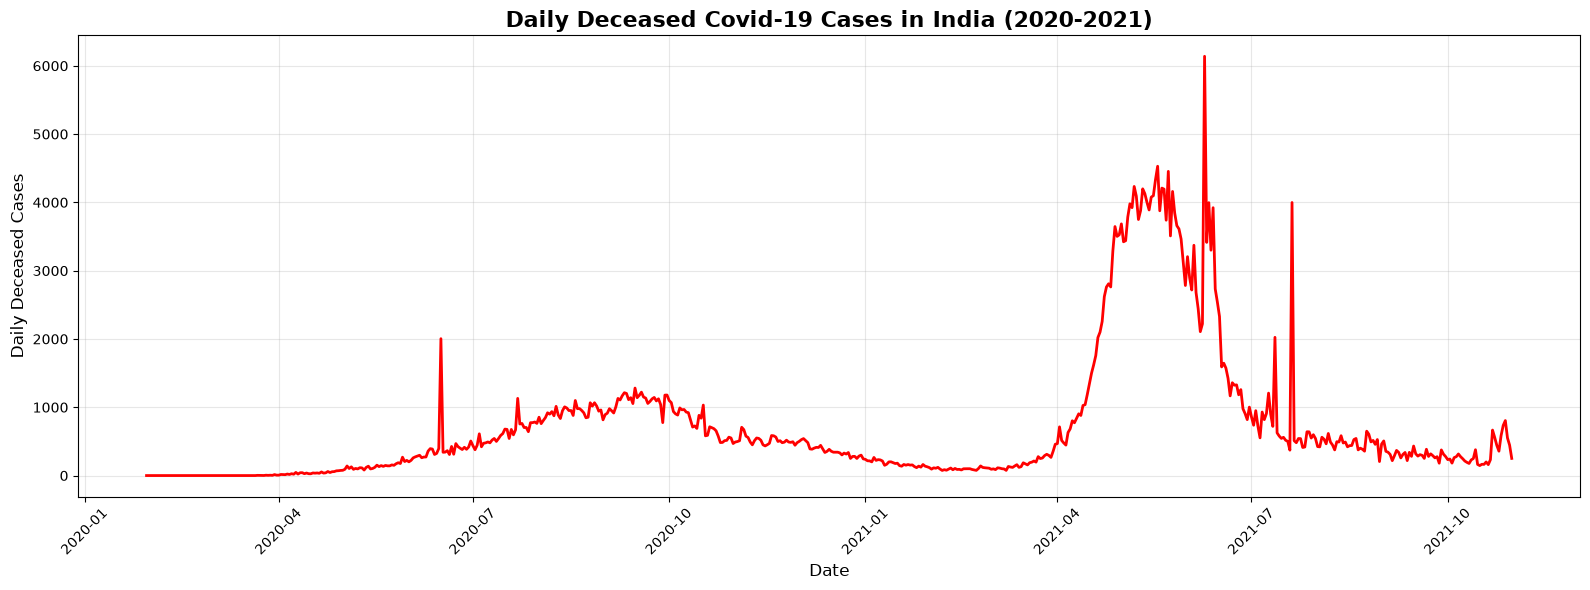

In [110]:
plt.figure(figsize=(16,6))
plt.plot(cases["Date_YMD"], cases["Daily Deceased"] , color="red", linewidth=2)
plt.title("Daily Deceased Covid-19 Cases in India (2020-2021)",fontsize=16,fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Deceased Cases", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/daily_deceased_cases.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 3: Daily Deceased COVID-19 Cases in India (2020–2021)

### 📌 Objective

Study the trend of daily COVID-19 deaths in India and identify periods with the highest mortality.

### 📈 Why a Line Chart?

A line chart is suitable for visualizing daily changes in mortality over time and identifying major peaks during the pandemic.

### 🔍 Key Insights

- Daily deaths remained relatively low during the initial months.
- Mortality increased during the first wave in 2020.
- The highest number of daily deaths occurred during the second wave in 2021.
- Several sharp spikes indicate days with exceptionally high reported fatalities.
- Death counts declined after the second wave subsided.

### 💼 Business / Public Health Insight

Monitoring mortality trends helps governments assess pandemic severity, improve healthcare planning, and strengthen emergency response systems during future outbreaks.

### 📚 Conclusion

The analysis shows that the second COVID-19 wave caused the highest mortality in India, emphasizing the importance of preparedness and healthcare capacity.

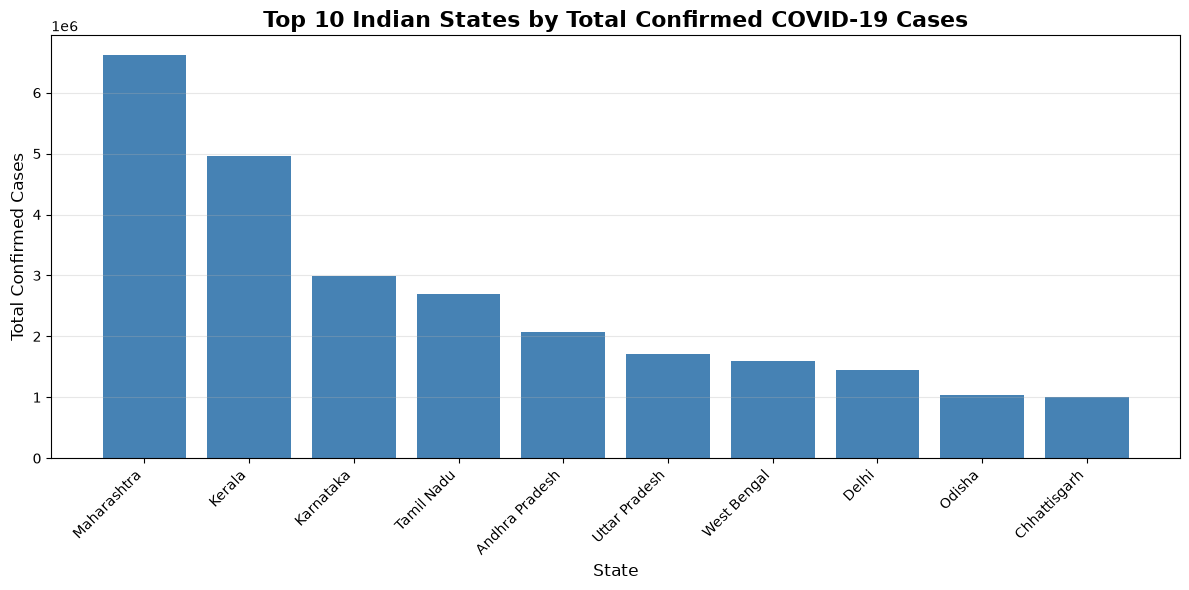

In [111]:
latest_state_data = (states.sort_values("Date").groupby("State").last())
latest_state_data = latest_state_data.drop("India")
latest_state_data.shape

top10_confirmed = latest_state_data.sort_values(by="Confirmed",ascending=False).head(10)
top10_confirmed

plt.figure(figsize=(12,6))
plt.bar(top10_confirmed.index, top10_confirmed["Confirmed"] , color="steelblue")
plt.title("Top 10 Indian States by Total Confirmed COVID-19 Cases",fontsize=16,fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Confirmed Cases", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("images/top10_confirmed_cases.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 4: Top 10 Indian States by Total Confirmed COVID-19 Cases

### 📌 Objective
Compare the 10 Indian states with the highest cumulative confirmed COVID-19 cases during the 2020–2021 period.

### 📈 Why a Bar Chart?
A **bar chart** is used because we are comparing **different categories (states)** based on a single numerical value (total confirmed cases). The height of each bar makes comparisons easy.

### 🔍 Key Insights

- Maharashtra recorded the **highest number of confirmed COVID-19 cases**, making it the most affected state during the study period.
- Kerala ranked **second**, followed by Karnataka and Tamil Nadu.
- Most of the top-ranked states are **highly urbanized**, suggesting that population density and mobility contributed to faster virus transmission.
- There is a noticeable gap between Maharashtra and the remaining states, highlighting its significantly higher case count.
- Even the 10th ranked state crossed **1 million confirmed cases**, indicating the widespread impact of the pandemic across India.

### 💼 Business / Public Health Insight

This visualization helps identify regions that required greater healthcare resources, testing capacity, hospital infrastructure, and vaccination efforts. Such comparisons can assist policymakers in allocating medical resources more effectively during large-scale outbreaks.

### 📚 Conclusion

The analysis reveals that Maharashtra, Kerala, Karnataka, and Tamil Nadu experienced the highest cumulative COVID-19 burden, emphasizing the relationship between urbanization, population movement, and disease spread.

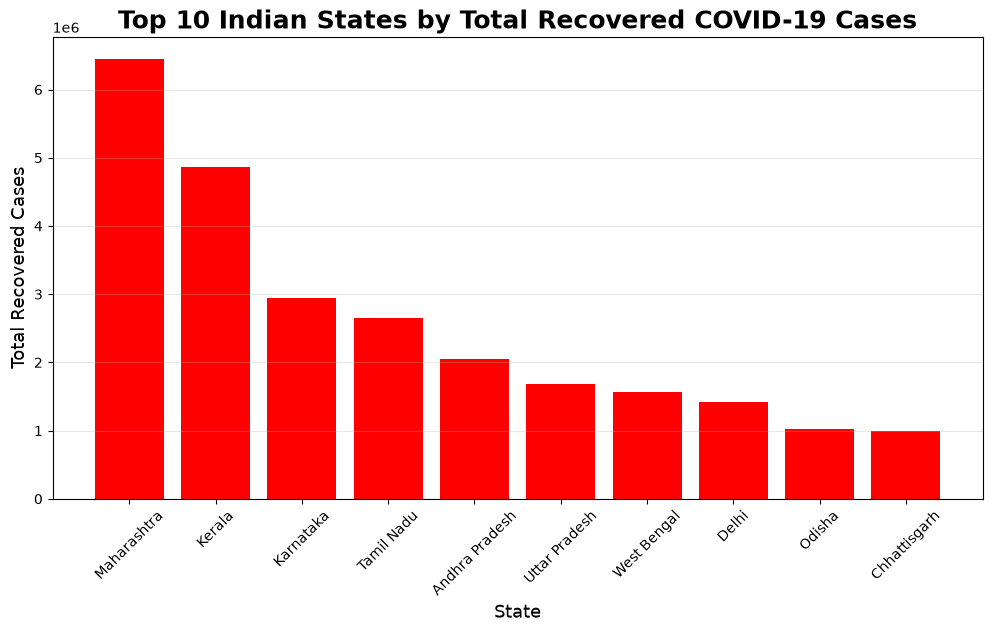

In [112]:
latest = states.groupby("State").last()
latest = latest.drop("India")
top_recovered = latest.sort_values(by = "Recovered" , ascending = False).head(10)

plt.figure(figsize=(12,6))
plt.bar( top_recovered.index, top_recovered["Recovered"] , color = "red")
plt.title("Top 10 Indian States by Total Recovered COVID-19 Cases",fontsize=18,fontweight="bold")
plt.xlabel("State", fontsize=13)
plt.ylabel("Total Recovered Cases", fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.savefig("images/top10_recovered_states.png", dpi=300,bbox_inches="tight")
plt.show()

# 📊 Chart 5: Top 10 Indian States by Total Recovered COVID-19 Cases

## 📌 Objective
Identify the top 10 Indian states with the highest cumulative recovered COVID-19 cases during the COVID-19 pandemic.

## 📈 Why this chart?
A bar chart is the most appropriate visualization for comparing recovery counts across different states. The height of each bar clearly represents the total recovered cases, making it easy to compare state-wise performance.

## 🔍 Key Insights
- Maharashtra recorded the highest number of recovered COVID-19 cases.
- Kerala ranked second, followed by Karnataka and Tamil Nadu.
- States with higher confirmed cases also reported higher recovery counts.
- Recovery counts varied significantly across states, reflecting differences in outbreak intensity and population size.

## 💼 Business/Public Health Insight
A higher number of recoveries does not necessarily indicate better healthcare performance. It often corresponds to a higher number of confirmed infections. To accurately evaluate healthcare effectiveness, recovery rates should be analyzed alongside total confirmed cases and fatality rates.

## 📚 Conclusion
The analysis shows that Maharashtra, Kerala, Karnataka, and Tamil Nadu accounted for the largest share of COVID-19 recoveries in India. This chart helps identify the states with the highest recovery burden and provides a foundation for comparing recovery rates with confirmed and deceased cases in subsequent analyses.

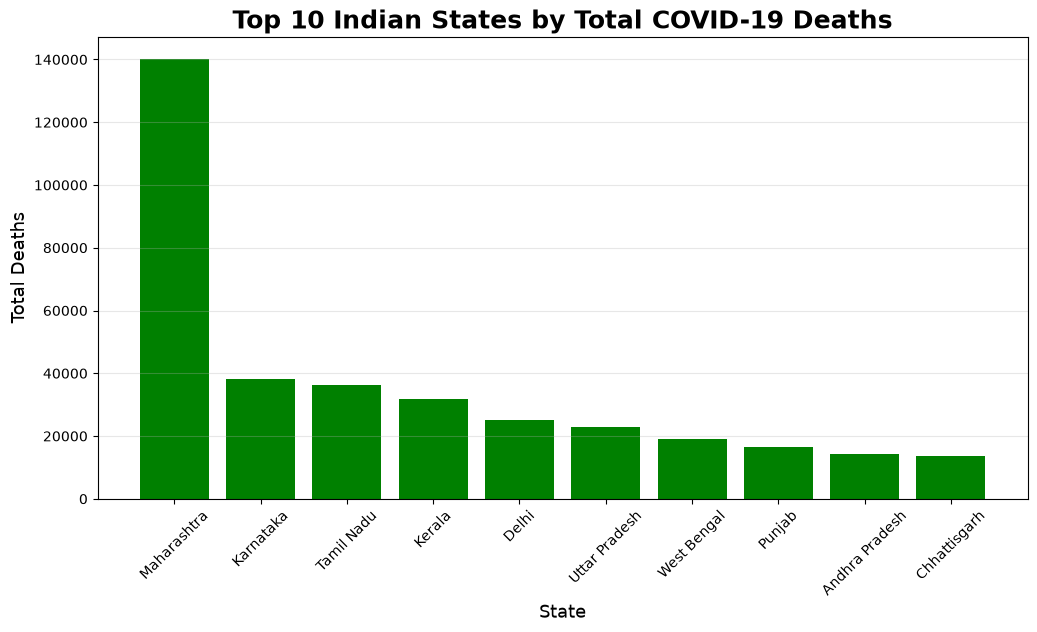

In [113]:
latest = states.groupby("State").last()
latest = latest.drop("India")

top_deceased = latest.sort_values(by="Deceased", ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top_deceased.index, top_deceased["Deceased"], color = "green")
plt.title("Top 10 Indian States by Total COVID-19 Deaths",fontsize=18,fontweight="bold")
plt.xlabel("State", fontsize=13)
plt.ylabel("Total Deaths", fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.savefig("images/top10_deceased_states.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 6: Top 10 Indian States by Total COVID-19 Deaths

### 📌 Objective
To identify the top 10 Indian states with the highest cumulative COVID-19 deaths by the end of the dataset.

### 📈 Why this chart?
A bar chart is used because it is the most suitable visualization for comparing numerical values across different categories (states). The height of each bar represents the total number of deaths.

### 🔍 Key Insights
- Maharashtra recorded the highest number of COVID-19 deaths among all states.
- Karnataka, Tamil Nadu, and Kerala also experienced a high death toll.
- There is a significant difference between Maharashtra and the remaining states.
- The variation indicates that the pandemic affected states differently in terms of mortality.

### 💼 Business / Public Health Insight
This analysis helps governments and healthcare organizations identify the states that were most severely impacted. Such information supports better allocation of healthcare resources, emergency planning, and policy decisions during future outbreaks.

### 📚 Conclusion
Maharashtra was the most affected state in terms of cumulative COVID-19 deaths, followed by Karnataka and Tamil Nadu. Comparing total deaths across states helps understand the overall impact of the pandemic and assists in future public health planning.

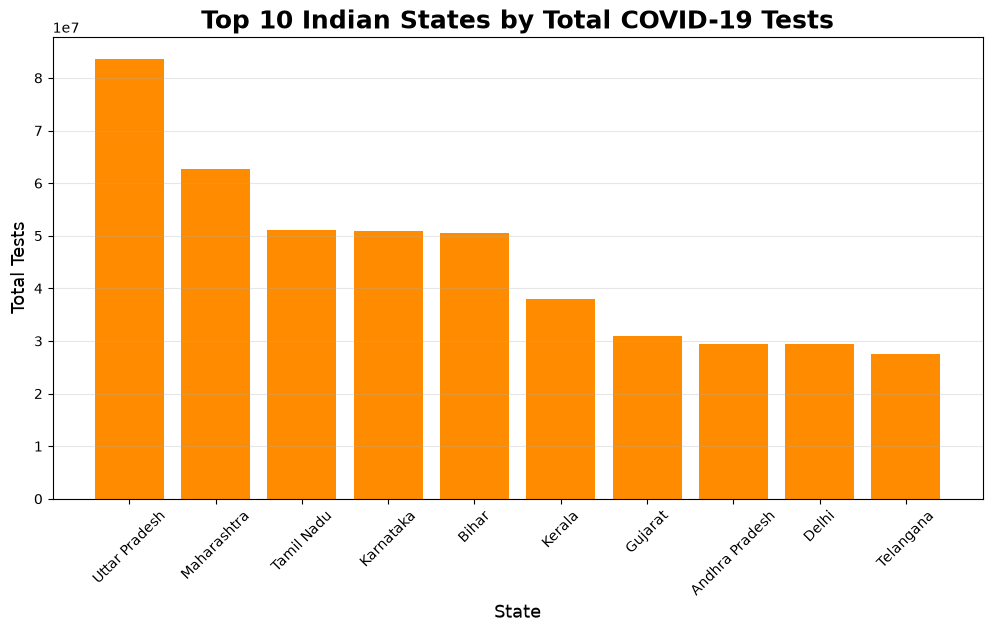

In [114]:
latest = states.groupby("State").last()
latest = latest.drop("India")
top_tested = latest.sort_values(by="Tested", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_tested.index,top_tested["Tested"],color="darkorange")
plt.title("Top 10 Indian States by Total COVID-19 Tests",fontsize=18,fontweight="bold")
plt.xlabel("State", fontsize=13)
plt.ylabel("Total Tests", fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.savefig("images/top10_tested_states.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 7: Top 10 Indian States by Total COVID-19 Tests

### 📌 Objective
To identify the top 10 Indian states that conducted the highest number of COVID-19 tests by the end of the dataset.

### 📈 Why this chart?
A bar chart is used because it is the most effective way to compare testing volumes across different states. The height of each bar represents the total number of COVID-19 tests conducted.

### 🔍 Key Insights
- Uttar Pradesh conducted the highest number of COVID-19 tests among all Indian states.
- Maharashtra ranked second despite recording the highest number of confirmed COVID-19 cases.
- Tamil Nadu, Karnataka, and Bihar also performed a large number of tests, indicating strong testing efforts.
- The differences in testing volumes highlight variations in healthcare infrastructure and testing capacity across states.

### 💼 Business / Public Health Insight
Large-scale testing is essential for early detection, isolation of infected individuals, and controlling the spread of infectious diseases. Comparing testing volumes helps policymakers evaluate healthcare preparedness, laboratory capacity, and the effectiveness of public health strategies.

### 📚 Conclusion
Uttar Pradesh led the country in total COVID-19 testing, followed by Maharashtra and Tamil Nadu. The chart demonstrates that extensive testing plays a crucial role in disease surveillance and effective pandemic management.

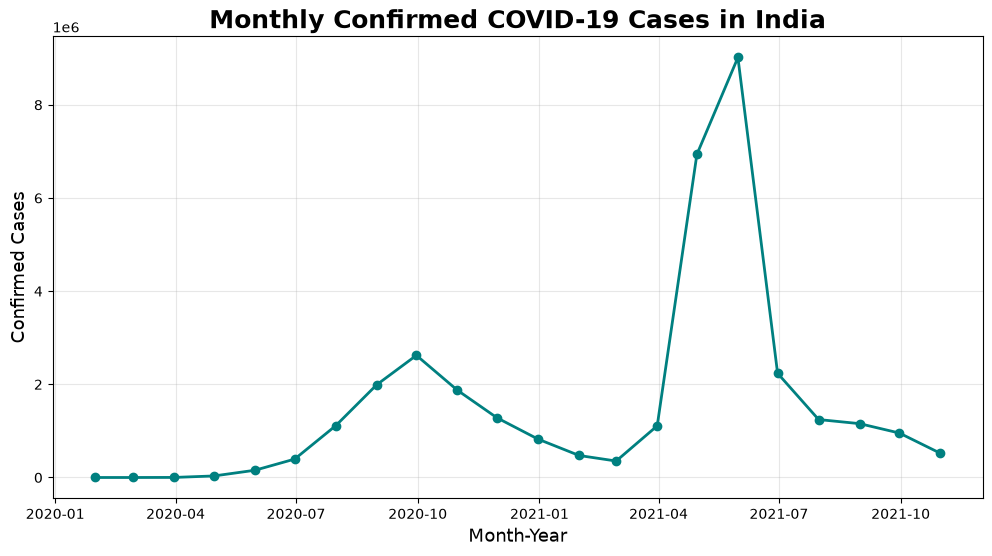

In [115]:
monthly_cases = (cases.resample("ME" , on = "Date")["Daily Confirmed"].sum())

plt.figure(figsize=(12,6))
plt.plot(monthly_cases.index,monthly_cases.values,marker="o",linewidth=2,color="teal")
plt.title("Monthly Confirmed COVID-19 Cases in India",fontsize=18,fontweight="bold")
plt.xlabel("Month-Year", fontsize=13)
plt.ylabel("Confirmed Cases", fontsize=13)
plt.grid(alpha=0.3)
plt.savefig("images/monthly_confirmed_cases.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 8: Monthly Confirmed COVID-19 Cases in India

### 📌 Objective

To analyze the monthly trend of confirmed COVID-19 cases in India during 2020–2021 and identify major infection waves.

### 📈 Why this chart?

- A line chart is ideal for visualizing trends over time.
- Monthly aggregation reduces daily fluctuations and highlights long-term patterns.
- It helps identify periods of rapid growth and decline in confirmed cases.

### 🔍 Key Insights

- Cases remained relatively low during the initial months of 2020.
- The first wave peaked around September–October 2020.
- Cases declined between November 2020 and March 2021.
- A much larger second wave occurred during April–May 2021.
- May 2021 recorded the highest number of monthly confirmed cases.

### 💼 Business / Public Health Insight

- Monthly trends help governments plan healthcare resources and policy interventions.
- Hospitals can prepare for future surges by analyzing previous infection patterns.
- Businesses can anticipate operational disruptions during high-transmission periods.

### 📚 Conclusion

The chart clearly highlights two major COVID-19 waves in India, with the second wave being significantly more severe than the first. Monthly trend analysis provides a clearer understanding of the pandemic's progression than daily data.

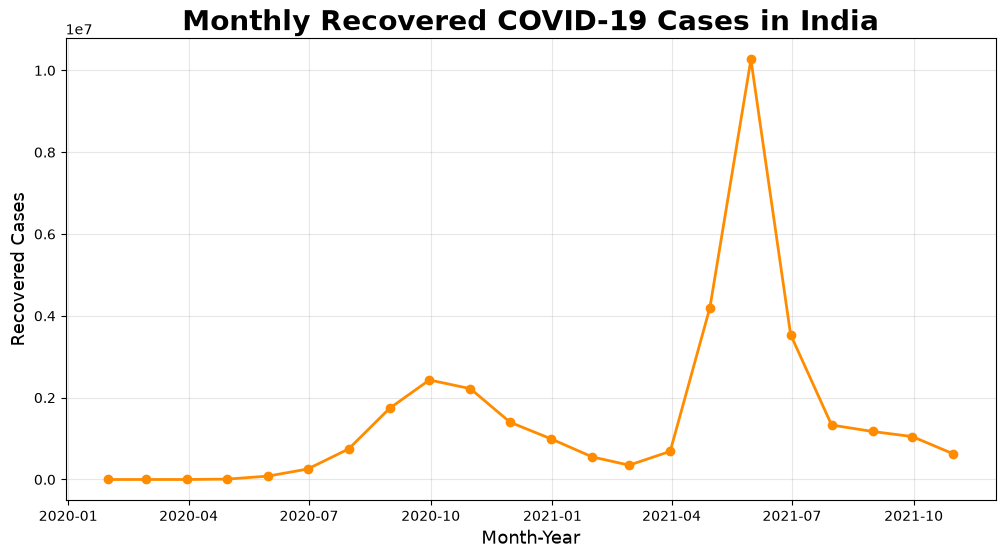

In [116]:
monthly_recovered = cases.resample("ME", on="Date")["Daily Recovered"].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_recovered.index,monthly_recovered.values,marker="o",linewidth=2,color="darkorange")
plt.title("Monthly Recovered COVID-19 Cases in India",fontsize=20,fontweight="bold")
plt.xlabel("Month-Year", fontsize=13)
plt.ylabel("Recovered Cases", fontsize=13)
plt.grid(alpha=0.3)
plt.savefig("images/monthly_recovered_cases.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 9: Monthly Recovered COVID-19 Cases in India

### 📌 Objective
To analyze the monthly trend of recovered COVID-19 cases in India during 2020–2021 and understand how recoveries changed throughout the pandemic.

### 📈 Why this chart?
A line chart is used because it is the most suitable visualization for showing trends over time. Monthly aggregation reduces daily fluctuations and clearly highlights the progression of COVID-19 recoveries.

### 🔍 Key Insights
- Recovery cases remained very low during the initial months of 2020.
- Recoveries increased significantly during the first COVID-19 wave and peaked around October 2020.
- Recovery cases declined after the first wave as infections reduced.
- A sharp rise occurred during the second wave, with May 2021 recording the highest monthly recoveries.
- Recovery trends closely followed confirmed case trends due to the natural delay between infection and recovery.

### 💼 Business / Public Health Insight
Monthly recovery trends help governments evaluate healthcare performance and hospital recovery capacity. Understanding recovery patterns also supports planning for medical resources, hospital discharges, and future pandemic preparedness.

### 📚 Conclusion
The chart demonstrates that recovery trends closely mirrored infection trends, with the highest recoveries occurring during the second wave. Monthly analysis provides a clearer understanding of India's healthcare response throughout the pandemic.

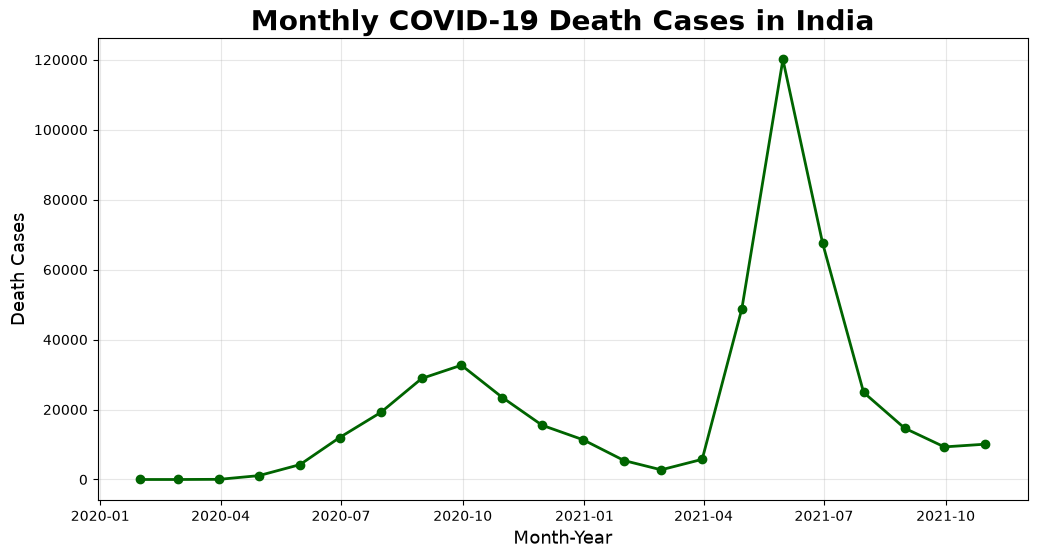

In [117]:

monthly_deceased = cases.resample("ME", on="Date")["Daily Deceased"].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_deceased.index , monthly_deceased.values , marker="o" , linewidth=2, color="darkgreen")
plt.title("Monthly COVID-19 Death Cases in India",fontsize=20,fontweight="bold")
plt.xlabel("Month-Year", fontsize=13)
plt.ylabel("Death Cases", fontsize=13)
plt.grid(alpha=0.3)
plt.savefig("images/monthly_death_cases.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 10: Monthly COVID-19 Death Cases in India

### 📌 Objective
To analyze the monthly trend of COVID-19 deaths in India during 2020–2021 and identify the periods with the highest mortality during the pandemic.

### 📈 Why this chart?
A line chart is used because it is the most suitable visualization for showing how death cases changed over time. Monthly aggregation reduces daily fluctuations and clearly highlights the overall mortality trend across different phases of the pandemic.

### 🔍 Key Insights
- Monthly death cases remained negligible during the initial months of 2020.
- Deaths increased steadily during the first COVID-19 wave, reaching a peak around October 2020.
- Monthly deaths declined gradually after the first wave as infection rates decreased and healthcare systems adapted.
- A dramatic spike in deaths occurred during the second wave, with May 2021 recording the highest monthly death count.
- The second wave was significantly more severe than the first, indicating a much higher mortality burden.
- Death cases declined rapidly after the second wave, suggesting improved disease control, increased vaccination coverage, and better clinical management.

### 💼 Business / Public Health Insight
Monitoring monthly death trends enables governments and healthcare organizations to evaluate the severity of disease outbreaks and the effectiveness of public health interventions. These insights support emergency preparedness, healthcare resource allocation, vaccination strategies, and policy planning for future pandemics.

### 📚 Conclusion
The monthly death trend reveals two major COVID-19 waves in India, with the second wave causing substantially higher mortality than the first. This analysis highlights the importance of timely healthcare interventions, effective pandemic management, and continuous monitoring to minimize fatalities during large-scale public health emergencies.

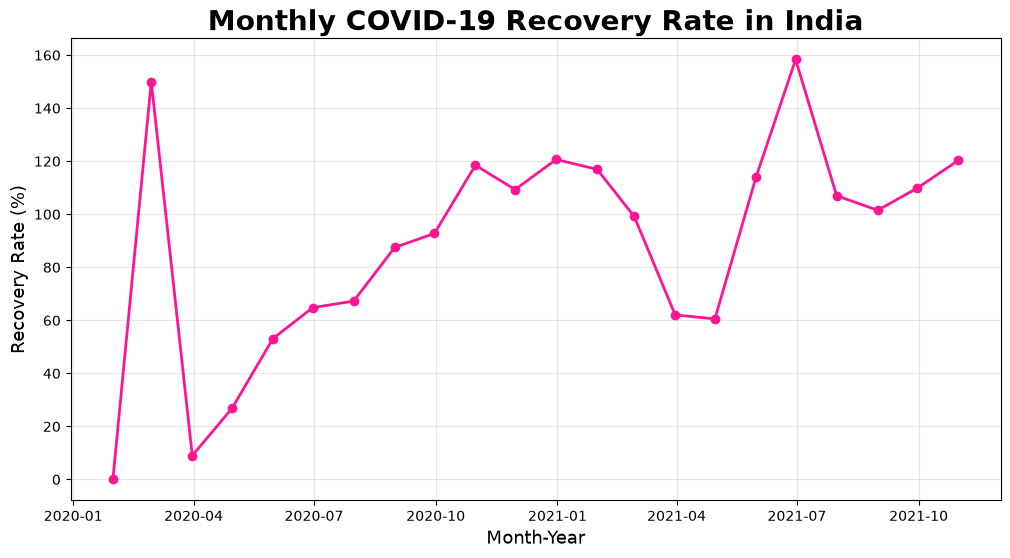

In [118]:
monthly_summary = cases.resample("ME", on="Date").sum(numeric_only=True)
monthly_summary["Recovery Rate"] = (monthly_summary["Daily Recovered"] / monthly_summary["Daily Confirmed"]) * 100

plt.figure(figsize=(12,6))
plt.plot(monthly_summary.index , monthly_summary["Recovery Rate"], marker="o", linewidth=2, color="deeppink")
plt.title("Monthly COVID-19 Recovery Rate in India",fontsize=20,fontweight="bold")
plt.xlabel("Month-Year", fontsize=13)
plt.ylabel("Recovery Rate (%)", fontsize=13)
plt.grid(alpha=0.3)
plt.savefig("images/monthly_recovery_rate.png", dpi=300, bbox_inches="tight")
plt.show()

## 📊 Chart 11: Monthly COVID-19 Recovery Rate in India

### 📌 Objective
To analyze the monthly COVID-19 recovery rate in India during 2020–2021 and observe how the proportion of recovered patients changed throughout different phases of the pandemic.

### 📈 Why this chart?
A line chart is used because it effectively shows changes in the recovery rate over time. Unlike absolute recovery counts, the recovery rate provides a relative measure of how recoveries compared to newly confirmed cases each month.

### 🔍 Key Insights
- The recovery rate fluctuated significantly during the initial months because the number of reported cases was relatively low.
- Recovery rates increased during several months, indicating that recoveries outpaced newly reported infections.
- Some months show a recovery rate exceeding 100%, which occurs because many patients recovered in a different month than the one in which they were diagnosed.
- Temporary declines in the recovery rate correspond to periods when new infections increased rapidly, especially during the second COVID-19 wave.
- Overall, the trend suggests improvements in patient recovery and healthcare management over time.

### 💼 Business / Public Health Insight
Monitoring recovery rates helps healthcare authorities evaluate treatment outcomes and understand the effectiveness of medical care during different stages of the pandemic. This metric can assist policymakers in assessing healthcare capacity and planning future public health responses.

### 📚 Conclusion
The monthly recovery rate generally improved as the pandemic progressed, reflecting better healthcare management and increased patient recoveries. However, monthly recovery rates should be interpreted carefully because recoveries often occur weeks after infection, which can produce values greater than 100% when comparing recoveries and confirmed cases within the same month.

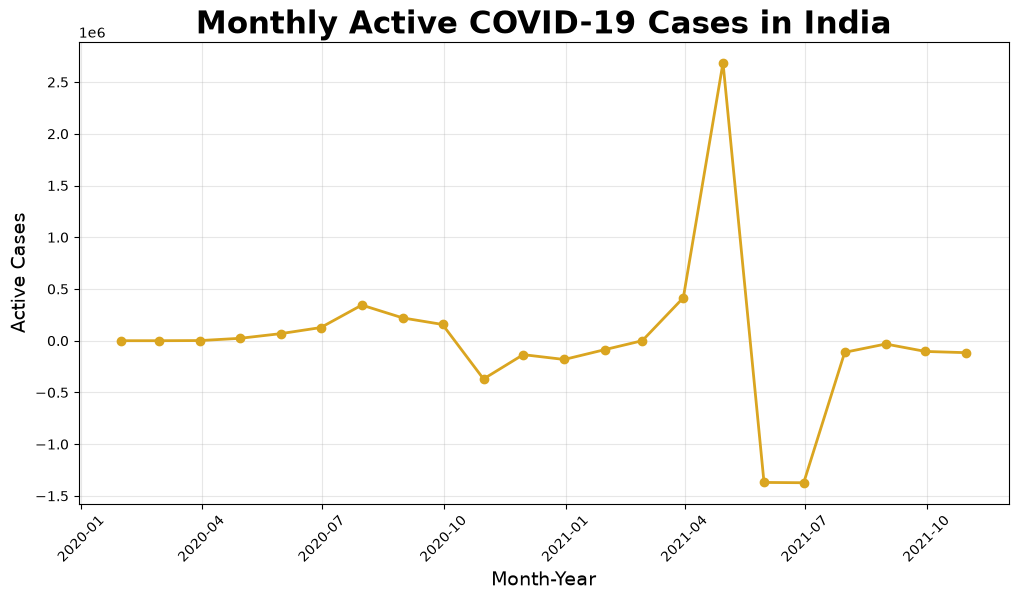

In [119]:
monthly_summary = cases.resample("ME", on="Date").sum(numeric_only=True)
monthly_summary["Active"] = ( monthly_summary["Daily Confirmed"] - monthly_summary["Daily Recovered"] - monthly_summary["Daily Deceased"])

plt.figure(figsize=(12,6))
plt.plot( monthly_summary.index, monthly_summary["Active"], marker="o", linewidth=2, color="goldenrod" )
plt.title( "Monthly Active COVID-19 Cases in India", fontsize=22,fontweight="bold")
plt.xlabel("Month-Year", fontsize=14)
plt.ylabel("Active Cases", fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.savefig( "images/monthly_active_cases.png", dpi=300, bbox_inches="tight")
plt.show()

## 📊 Chart 12: Monthly Active COVID-19 Cases in India

### 📌 Objective
To analyze the monthly change in active COVID-19 cases in India during 2020–2021 and understand how the balance between new infections, recoveries, and deaths changed over time.

### 📈 Why this chart?
A line chart is used because it effectively displays changes over time. Active cases are estimated using the formula:

**Active Cases = Daily Confirmed − Daily Recovered − Daily Deceased**

This helps visualize whether active infections were increasing or decreasing each month.

### 🔍 Key Insights
- Active cases increased steadily during the first COVID-19 wave in 2020, reaching a noticeable peak around August–September.
- A sharp surge occurred during the second wave in May 2021, indicating a rapid increase in active infections.
- The graph shows a significant drop into negative values after the second wave because monthly recoveries exceeded new confirmed cases during those months.
- By the later months of 2021, the monthly change in active cases remained close to zero or slightly negative, suggesting that the outbreak was gradually coming under control.

### 💼 Business / Public Health Insight
Tracking monthly changes in active cases helps governments and healthcare authorities understand periods of increasing or decreasing healthcare burden. Positive values indicate growing active infections, while negative values suggest that recoveries are outpacing new infections, reducing pressure on hospitals and healthcare resources.

### 📚 Conclusion
The monthly active case trend highlights the rapid growth of infections during India's COVID-19 waves and the subsequent decline as recoveries increased. The negative values after the second wave indicate that recovery efforts eventually surpassed the rate of new infections, marking an improvement in the overall pandemic situation.

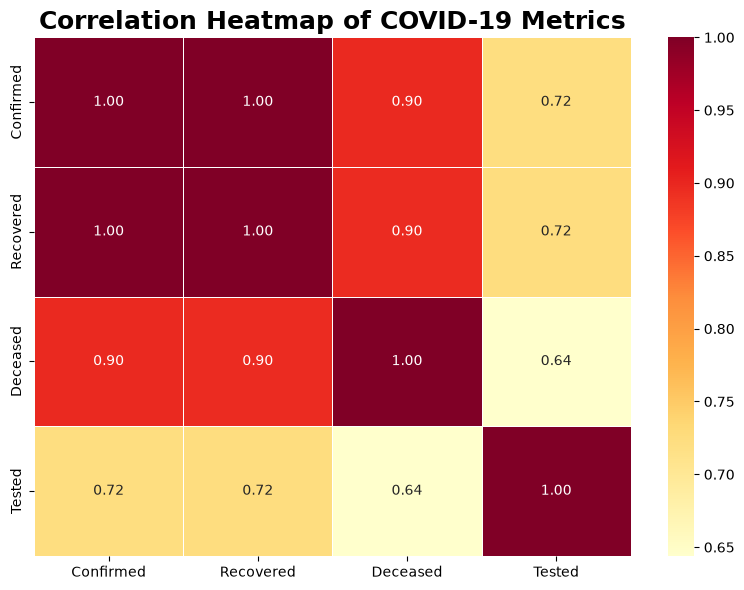

In [120]:
corr = latest[["Confirmed", "Recovered", "Deceased", "Tested"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="YlOrRd", fmt=".2f",linewidths=0.5)
plt.title( "Correlation Heatmap of COVID-19 Metrics", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 13: Correlation Heatmap of COVID-19 Metrics

### 📌 Objective
To examine the relationship between major COVID-19 metrics—Confirmed, Recovered, Deceased, and Tested—and understand how strongly they are correlated across Indian states.

### 📈 Why this chart?
A heatmap is used because it visually represents the correlation between multiple numerical variables using colors. It makes it easy to identify strong and weak relationships between COVID-19 metrics at a glance.

### 🔍 Key Insights
- Confirmed and Recovered cases have a perfect positive correlation (1.00), indicating that states with more confirmed cases also recorded more recoveries.
- Confirmed and Deceased cases show a very strong positive correlation (0.90), suggesting that states with larger outbreaks generally experienced higher mortality.
- Confirmed and Tested cases have a strong positive correlation (0.72), showing that increased testing was associated with identifying more COVID-19 cases.
- Recovered and Deceased cases are also highly correlated (0.90), reflecting that states with larger outbreaks recorded both more recoveries and more deaths.
- Tested and Deceased cases have the lowest correlation (0.64), indicating that mortality depends not only on testing but also on factors such as healthcare facilities, patient demographics, and disease severity.
- The diagonal values are all 1.00 because every variable is perfectly correlated with itself.

### 💼 Business / Public Health Insight
The correlation analysis helps policymakers and healthcare authorities understand how different COVID-19 indicators are related. It supports better decision-making for resource allocation, testing strategies, healthcare planning, and future pandemic preparedness.

### 📚 Conclusion
The correlation heatmap reveals strong positive relationships among confirmed cases, recoveries, deaths, and testing across Indian states. The analysis indicates that larger outbreaks were generally associated with increased testing, higher recoveries, and greater mortality, highlighting the interconnected nature of key pandemic indicators.

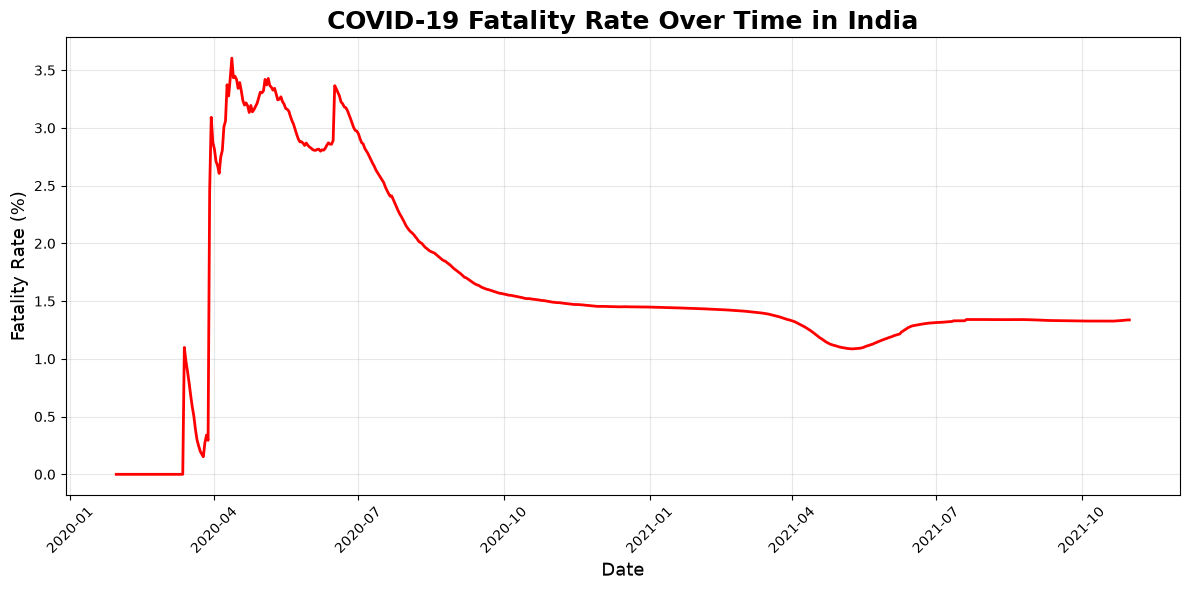

In [121]:
india = states[states["State"] == "India"].copy()
india["Fatality Rate"] = (india["Deceased"] / india["Confirmed"]) * 100

plt.figure(figsize=(12,6))
plt.plot(india["Date"], india["Fatality Rate"], color="red",linewidth=2)
plt.title("COVID-19 Fatality Rate Over Time in India", fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=13)
plt.ylabel("Fatality Rate (%)", fontsize=13)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/fatality_rate.png", dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 14: COVID-19 Fatality Rate Over Time in India

### 📌 Objective
To analyze how the COVID-19 fatality rate changed over time in India by comparing cumulative deaths with cumulative confirmed cases.

### 📈 Why this chart?
A line chart is used because it effectively shows changes in the fatality rate over time. Unlike total death counts, the fatality rate represents the percentage of confirmed cases that resulted in death, making it a more meaningful indicator of disease severity.

### 🔍 Key Insights
- The fatality rate was highly volatile during the early months of the pandemic due to the low number of confirmed cases.
- As COVID-19 cases increased, the fatality rate gradually stabilized.
- A gradual decline in the fatality rate was observed over time, indicating improvements in testing, medical treatment, and healthcare management.
- By the end of the dataset, the fatality rate remained relatively stable at around **1.3%**, suggesting better clinical outcomes despite large numbers of infections.

### 💼 Business / Public Health Insight
Tracking the fatality rate helps governments and healthcare authorities evaluate the severity of the pandemic and the effectiveness of medical interventions. A declining fatality rate can indicate improved healthcare capacity, timely diagnosis, better treatment protocols, and increased public awareness.

### 📚 Conclusion
The fatality rate provides a more meaningful assessment of COVID-19 severity than absolute death counts alone. The overall declining trend suggests that India's healthcare response improved over the course of the pandemic, resulting in a lower proportion of deaths among confirmed cases.

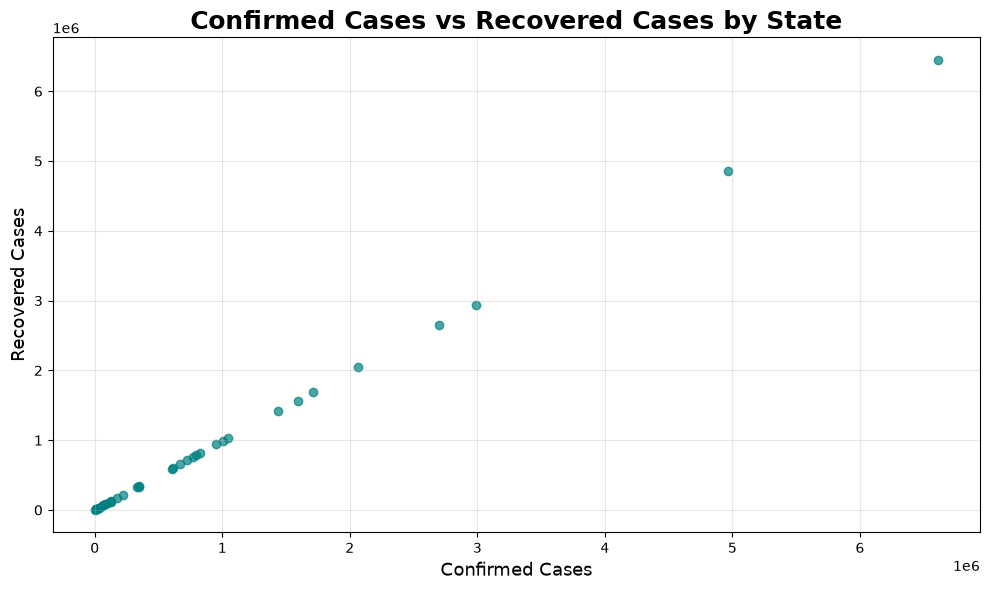

In [122]:
latest = states.groupby("State").last()
latest = latest.drop("India")

plt.figure(figsize=(10,6))
plt.scatter(latest["Confirmed"],latest["Recovered"],color="teal",alpha=0.7)
plt.title("Confirmed Cases vs Recovered Cases by State",fontsize=18,fontweight="bold")
plt.xlabel("Confirmed Cases", fontsize=13)
plt.ylabel("Recovered Cases", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/confirmed_vs_recovered_scatter.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 15: Confirmed Cases vs Recovered Cases by State (Scatter Plot)

### 📌 Objective
To examine the relationship between cumulative confirmed COVID-19 cases and cumulative recovered cases across different Indian states.

### 📈 Why this chart?
A scatter plot is used to visualize the relationship between two numerical variables. Each point represents a state, making it easy to observe whether states with higher confirmed cases also recorded higher recoveries. This chart is ideal for identifying patterns, trends, and possible correlations between the two variables.

### 🔍 Key Insights
- A strong positive relationship exists between confirmed and recovered cases across Indian states.
- States with a higher number of confirmed cases generally recorded a higher number of recoveries.
- Maharashtra, Kerala, Karnataka, Tamil Nadu, and Andhra Pradesh are positioned in the upper-right region, indicating both high confirmed and high recovered cases.
- Most smaller states are clustered near the lower-left corner, reflecting comparatively lower numbers of confirmed and recovered cases.
- The close alignment of points along an upward trend suggests that recoveries increased proportionally as confirmed cases increased.

### 💼 Business / Public Health Insight
Analyzing the relationship between confirmed and recovered cases helps healthcare authorities assess recovery patterns across states. A strong positive relationship indicates that despite varying outbreak sizes, states were able to recover a substantial proportion of infected individuals. Such analysis can support resource planning, healthcare capacity assessment, and evaluation of treatment effectiveness.

### 📚 Conclusion
The scatter plot demonstrates a strong positive correlation between confirmed and recovered COVID-19 cases across Indian states. As the number of confirmed infections increased, recoveries also increased significantly, indicating an overall effective healthcare response during the pandemic. This visualization reinforces the strong association observed in the correlation analysis.

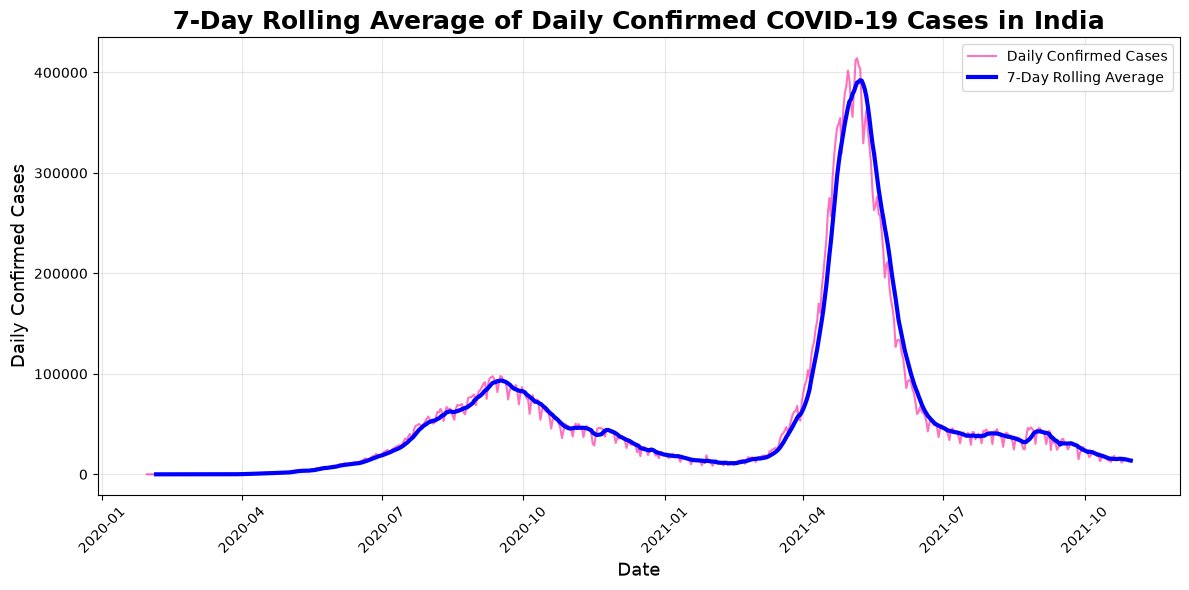

In [123]:
daily = cases.copy()
daily = daily.sort_values("Date_YMD")
daily["7-Day Rolling Average"] = (daily["Daily Confirmed"].rolling(window=7).mean())

plt.figure(figsize=(12,6))
plt.plot(daily["Date_YMD"], daily["Daily Confirmed"],color="deeppink",linewidth=1.5,alpha=0.6,label="Daily Confirmed Cases")
plt.plot(daily["Date_YMD"],daily["7-Day Rolling Average"],color="blue",linewidth=3,label="7-Day Rolling Average")
plt.title("7-Day Rolling Average of Daily Confirmed COVID-19 Cases in India",fontsize=18,fontweight="bold")
plt.xlabel("Date", fontsize=13)
plt.ylabel("Daily Confirmed Cases", fontsize=13)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("images/rolling_average_confirmed.png", dpi=300,bbox_inches="tight")
plt.show()

## 📊 Chart 16: 7-Day Rolling Average of Daily Confirmed COVID-19 Cases in India

### 📌 Objective
To smooth daily fluctuations in COVID-19 confirmed cases and identify the underlying trend of the pandemic using a 7-day rolling average.

### 📈 Why this chart?
A line chart with a 7-day rolling average is used to reduce short-term fluctuations caused by reporting delays, testing variations, and daily inconsistencies. Comparing the raw daily cases with the rolling average provides a clearer picture of the overall trend.

### 🔍 Key Insights
- Daily confirmed cases show significant day-to-day fluctuations throughout the pandemic.
- The 7-day rolling average smooths these fluctuations and clearly highlights the overall trend.
- The first COVID-19 wave peaked around September 2020, while the second wave reached a much higher peak during April–May 2021.
- Following the second wave, both daily cases and the rolling average declined steadily, indicating a reduction in infections.

### 💼 Business / Public Health Insight
Rolling averages are widely used by governments, healthcare organizations, and researchers because they provide a more reliable measure of disease trends than daily reported cases. They help policymakers monitor the progression of outbreaks, allocate healthcare resources, and make informed public health decisions.

### 📚 Conclusion
The 7-day rolling average effectively removes daily reporting noise and reveals the true progression of COVID-19 cases in India. It clearly highlights both pandemic waves and demonstrates why moving averages are a standard tool in time-series analysis.

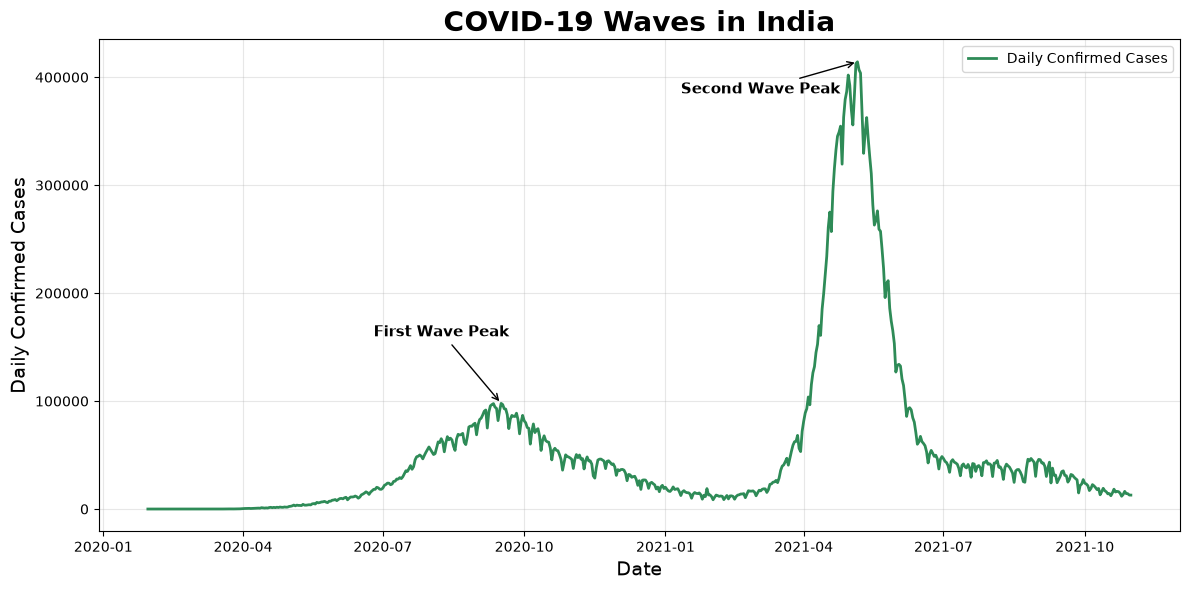

In [124]:
daily = cases.sort_values("Date_YMD")
first_wave = daily[daily["Date_YMD"] < "2021-01-01"]
second_wave = daily[daily["Date_YMD"] >= "2021-01-01"]

first_peak = first_wave.loc[first_wave["Daily Confirmed"].idxmax()]
second_peak = second_wave.loc[second_wave["Daily Confirmed"].idxmax()]

plt.figure(figsize=(12,6))
plt.plot(daily["Date_YMD"], daily["Daily Confirmed"], color="seagreen", linewidth=2, label="Daily Confirmed Cases")
plt.annotate("First Wave Peak", xy=(first_peak["Date_YMD"], first_peak["Daily Confirmed"]), xytext=(pd.Timestamp("2020-06-25"), 160000), arrowprops=dict(arrowstyle="->", color="black"), fontsize=11, fontweight="bold")
plt.annotate("Second Wave Peak", xy=(second_peak["Date_YMD"], second_peak["Daily Confirmed"]), xytext=(pd.Timestamp("2021-01-11"), 385000), arrowprops=dict(arrowstyle="->", color="black"), fontsize=11, fontweight="bold")
plt.title("COVID-19 Waves in India", fontsize=20, fontweight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily Confirmed Cases", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/covid_waves_india.png", dpi=300, bbox_inches="tight")
plt.show()

# 📊 Chart 16: COVID-19 Waves in India (First Wave & Second Wave)

### 📌 Objective
To identify and visualize the two major waves of the COVID-19 pandemic in India by highlighting the peak of daily confirmed cases during each wave.

### 📈 Why this chart?
A line chart is the most appropriate visualization because it shows how daily confirmed COVID-19 cases changed continuously over time. Annotating the two highest peaks helps clearly distinguish the first and second waves of the pandemic.

### 🔍 Key Insights
- The **First Wave** peaked around **September 2020**, with nearly **100,000 daily confirmed cases**.
- The **Second Wave** reached its peak around **May 2021**, crossing **400,000 daily confirmed cases**, making it significantly more severe.
- The second wave rose much more rapidly than the first, indicating a faster spread of infections.
- After each peak, daily cases gradually declined as control measures and vaccination efforts were implemented.

### 💼 Business / Public Health Insight
Identifying pandemic waves helps governments and healthcare organizations understand the intensity and timing of disease outbreaks. Such analysis supports better hospital resource planning, emergency preparedness, vaccination strategies, and timely policy interventions during future public health crises.

### 📚 Conclusion
The visualization clearly highlights that India experienced two major COVID-19 waves, with the second wave being substantially larger than the first. Annotating the wave peaks makes it easier to understand the progression of the pandemic and provides valuable insights for epidemiological analysis and future outbreak management.

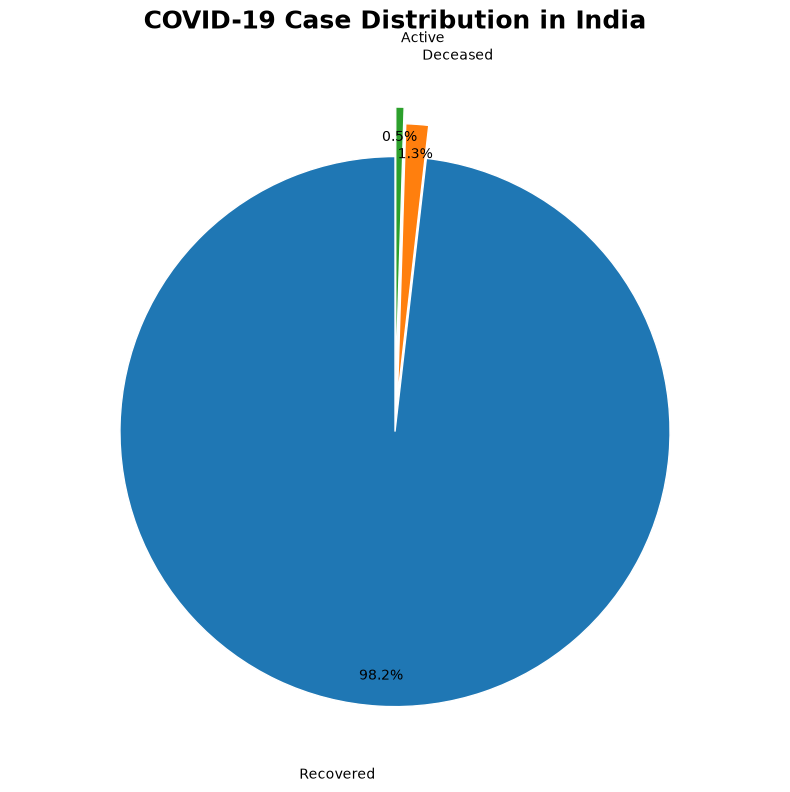

In [125]:
latest_data = cases.iloc[-1]
labels = ["Recovered", "Deceased", "Active"]
active_cases = latest_data["Total Confirmed"] - latest_data["Total Recovered"] - latest_data["Total Deceased"]
sizes = [latest_data["Total Recovered"], latest_data["Total Deceased"], active_cases]

plt.figure(figsize=(8,8))
plt.pie(sizes,labels=labels,autopct="%1.1f%%",startangle=90,explode=(0,0.12,0.18),shadow=False,pctdistance=0.89,labeldistance=1.25,wedgeprops={"edgecolor":"white","linewidth":1})
plt.title("COVID-19 Case Distribution in India", fontsize=18, fontweight="bold", pad=35)
plt.axis("equal")
plt.tight_layout()
plt.savefig("images/covid_case_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 📊 Chart 17: COVID-19 Case Distribution in India

### 📌 Objective
To visualize the overall distribution of COVID-19 cases in India by comparing the proportions of recovered, deceased, and active cases using a pie chart.

### 📈 Why this chart?
A pie chart is suitable for showing how different categories contribute to a whole. It provides a quick overview of the proportion of recovered, deceased, and active cases in the latest available COVID-19 data.

### 🔍 Key Insights
- **Recovered cases accounted for approximately 98.2%** of the total cases, indicating that the vast majority of infected individuals recovered.
- **Deceased cases represented about 1.3%** of the total confirmed cases.
- **Active cases accounted for only about 0.5%**, showing that very few cases remained active at the end of the dataset.
- The dominance of the recovered category reflects the significant improvement in patient recovery over the course of the pandemic.

### 💼 Business / Public Health Insight
Understanding the distribution of case outcomes helps public health authorities evaluate the overall impact of the pandemic. A high recovery percentage indicates effective treatment, healthcare management, and vaccination efforts, while the proportions of active and deceased cases provide insights into the remaining healthcare burden and disease severity.

### 📚 Conclusion
The pie chart demonstrates that by the end of the analyzed period, the overwhelming majority of COVID-19 cases in India had recovered, while only a small percentage remained active or resulted in fatalities. This visualization provides a concise summary of the pandemic's final outcome and highlights the overall recovery trend in the country.

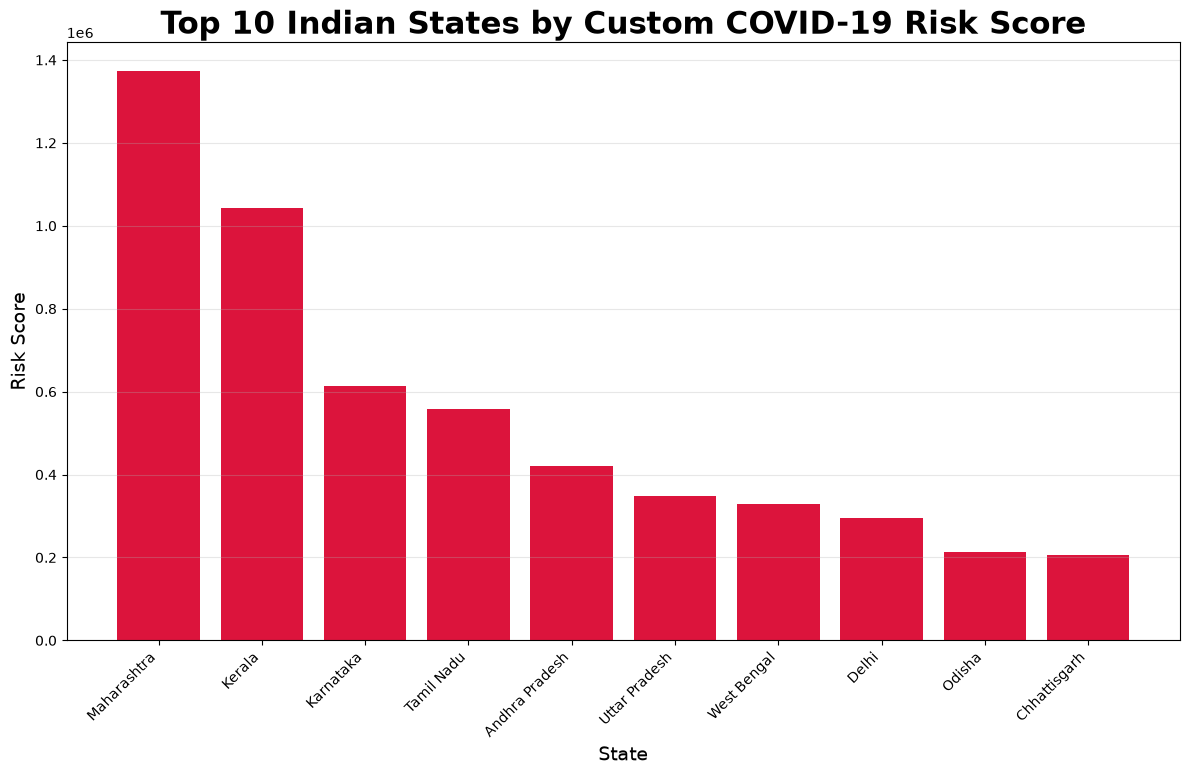

In [126]:
latest = states.groupby("State").last()
latest = latest.drop("India")
latest["Active"] = latest["Confirmed"] - latest["Recovered"] - latest["Deceased"]
latest["Risk Score"] = (latest["Active"] * 0.5 +latest["Deceased"] * 0.3 +latest["Confirmed"] * 0.2)
risk = latest.sort_values("Risk Score", ascending=False).head(10)

plt.figure(figsize=(12,8))
plt.bar(risk.index, risk["Risk Score"], color="crimson")
plt.title("Top 10 Indian States by Custom COVID-19 Risk Score", fontsize=22, weight="bold")
plt.xlabel("State", fontsize=14)
plt.ylabel("Risk Score", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("images/custom_risk_score.png", dpi=300, bbox_inches="tight")
plt.show()



# Note: The COVID-19 Risk Score shown in this analysis is a custom metric created for exploratory data analysis by combining confirmed, active, and deceased cases using user-defined weights.It is not an official epidemiological risk index.

# 📊 Chart 18: Top 10 Indian States by Custom COVID-19 Risk Score

### 📌 Objective
To rank the top 10 Indian states based on a custom COVID-19 Risk Score that combines confirmed cases, active cases (derived), and deceased cases into a single metric for comparative analysis.

### 📈 Why this chart?
A bar chart is the most suitable visualization for comparing a calculated metric across multiple categories (states). It clearly highlights which states experienced the highest overall COVID-19 burden according to the custom risk score.

### 🔍 Key Insights
- Maharashtra recorded the highest custom COVID-19 Risk Score, indicating the greatest overall pandemic burden.
- Kerala ranked second, followed by Karnataka and Tamil Nadu.
- Andhra Pradesh, Uttar Pradesh, West Bengal, and Delhi also appeared among the top high-risk states.
- The noticeable difference in bar heights shows that the impact of COVID-19 varied considerably across states.

### 💼 Business / Public Health Insight
A custom risk score provides a single metric for comparing multiple COVID-19 indicators simultaneously. Although this score is designed for exploratory analysis and is not an official epidemiological measure, it demonstrates how feature engineering can help identify regions requiring greater healthcare attention and resource allocation.

### 📚 Conclusion
The custom COVID-19 Risk Score combines confirmed cases, active cases, and deaths into one analytical metric, making it easier to compare the overall severity of the pandemic across Indian states. This visualization illustrates the practical application of feature engineering and ranking techniques in data analysis.